# Evaluación 2
## Programación Científica 2026-1

**Estudiante:** Laura Gómez Angulo

**Cédula:** 1017929190

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

datos = np.load("../SolucionReferencia_0000/datos_0000.npz")

X = jnp.array(datos["X"])
y = jnp.array(datos["y"])
t = jnp.array(datos["t"])

"""
Antes de aplicar la transformada, es necesario organizar los datos.
En esta sección separamos la señal original utilizando máscaras booleanas basadas en las etiquetas (y).
Esto nos permite aislar cada régimen del sistema y analizar su comportamiento de forma independiente
"""

'\nAntes de aplicar la transformada, es necesario organizar los datos.\nEn esta sección separamos la señal original utilizando máscaras booleanas basadas en las etiquetas (y).\nEsto nos permite aislar cada régimen del sistema y analizar su comportamiento de forma independiente\n'

In [2]:
print(X.shape)
print(X[0].shape)

(24, 256)
(256,)


In [3]:
def capa_fourier(t, K):

    k_vals = jnp.arange(1, K + 1)

    argumentos = 2 * jnp.pi * jnp.outer(t, k_vals)

    senos = jnp.sin(argumentos)
    cosenos = jnp.cos(argumentos)

    return jnp.concatenate([senos, cosenos], axis=1)

In [4]:
t = np.linspace(0, 1, 256)
W1 = capa_fourier(t, K=25)

print(W1.shape)

(256, 50)


In [5]:
x = X[0]

print(x.shape)

(256,)


In [6]:
coef = x @ W1

print(coef.shape)

(50,)


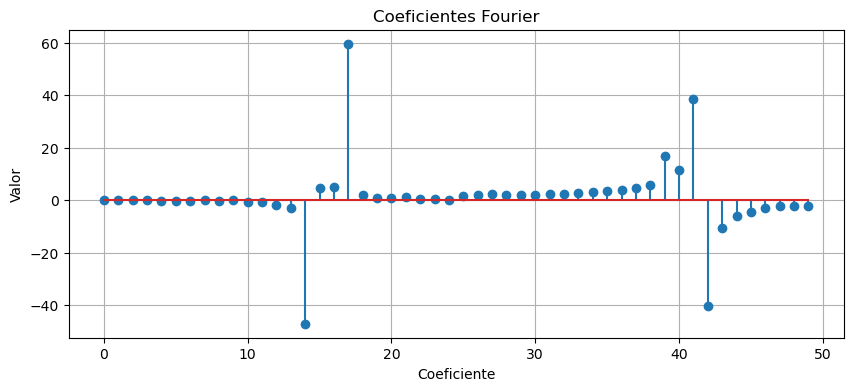

In [7]:
plt.figure(figsize=(10,4))

plt.stem(coef)

plt.xlabel("Coeficiente")
plt.ylabel("Valor")
plt.grid(True)

plt.title("Coeficientes Fourier")

plt.show()

In [8]:
def red(params, x):

    W1, W2 = params

    h = jnp.tanh(W1 @ x)

    x_hat = W2 @ h

    return x_hat

In [9]:
def init_random():

    key = jax.random.PRNGKey(1)

    k1,k2 = jax.random.split(key)

    W1 = 0.01 * jax.random.normal(
        k1,
        (50,256)
    )

    W2 = 0.01 * jax.random.normal(
        k2,
        (256,50)
    )

    return [W1,W2]

In [10]:
def init_fourier():
    """
    Inicializa los pesos del modelo basándose en los coeficientes de Fourier.
    Esta estrategia inyecta conocimiento previo al modelo para intentar
    reducir el error inicial y acelerar el entrenamiento.
    """

    W1 = jnp.array(capa_fourier(t, K=25)).T # Transpose W1 to get shape (50, 256)
    key = jax.random.PRNGKey(0)

    W2 = 0.01 * jax.random.normal(
        key,
        (256,50)
    )
    return [W1,W2]

In [11]:
red_vmap = jax.vmap(red, in_axes=(None, 0))

def loss(params, X):

    X_hat = red_vmap(params, X)
    return jnp.mean((X_hat - X)**2)

In [12]:
import numpy as np

def iteracion_umbral(historial_loss, umbral=0.15):
    """
    Encuentra la primera iteración donde el error de pérdida cae por debajo del umbral.
    Retorna un solo número (el índice de la iteración).
    """
    loss_array = np.array(historial_loss)


    indices = np.where(loss_array < umbral)[0]

    if len(indices) > 0:
        return indices[0]
    else:
        return "El modelo nunca alcanzó el umbral"

In [13]:
grad_loss = jax.grad(loss)

@jax.jit
def update(params, X, lr=0.05):
    grads = grad_loss(params, X)

    nuevos = [
        p - lr * g
        for p, g in zip(params, grads)
    ]

    return nuevos

En este bloque definimos la arquitectura del modelo. Para maximizar la eficiencia computacional, utilizamos el ecosistema de JAX: vectorizamos las operaciones a lo largo del lote de datos con jax.vmap y compilamos la función de actualización de gradientes con @jax.jit, logrando un entrenamiento mucho más rápido.

In [14]:
def error_relativo(x, x_hat):

    return (
        np.linalg.norm(
            np.array(x_hat) - np.array(x)
        )
        /
        np.linalg.norm(
            np.array(x)
        )
    )

In [15]:
def train(params, X,
          epochs=3000,
          lr=0.05):

    historial = []

    for i in range(epochs):

        params = update(
            params,
            X,
            lr
        )

        if i % 10 == 0:

            L = loss(
                params,
                X
            )

            historial.append(
                float(L)
            )

    return params, historial

In [16]:
params_fourier = init_fourier()

print(
    loss(params_fourier,X)
) # Re-initializing params_fourier to pick up latest function definitions

0.6816118


In [17]:
print(X.shape)
print(y.shape)


(24, 256)
(24,)


In [18]:
print(np.unique(y))


[0 1 2]


In [19]:
print("Régimen 0:", np.sum(y == 0))
print("Régimen 1:", np.sum(y == 1))
print("Régimen 2:", np.sum(y == 2))


Régimen 0: 8
Régimen 1: 8
Régimen 2: 8


In [20]:
X0 = X[y == 0]
X1 = X[y == 1]
X2 = X[y == 2]

print(X0.shape)
print(X1.shape)
print(X2.shape)


(8, 256)
(8, 256)
(8, 256)


In [21]:
x = X0[0]

coef = np.abs(
    np.fft.rfft(x)
)

energia = coef**2

energia_total = energia.sum()

energia_ordenada = np.sort(
    energia
)[::-1]

energia_acumulada = np.cumsum(
    energia_ordenada
)

fraccion = (
    energia_acumulada
    /
    energia_total
)

In [22]:
errores = []

coef_fft = np.fft.rfft(x)

for k in range(1, len(coef_fft)+1):

    indices = np.argsort(
        np.abs(coef_fft)
    )[::-1]

    nuevo = np.zeros_like(
        coef_fft
    )

    nuevo[
        indices[:k]
    ] = coef_fft[
        indices[:k]
    ]

    x_rec = np.fft.irfft(
        nuevo,
        n=len(x)
    )

    err = np.linalg.norm(
        x - x_rec
    ) / np.linalg.norm(x)

    errores.append(err)

# **Regimen 0**

In [23]:
params_fourier_0 = init_fourier()

params_fourier_0, hist_fourier_0 = train(
    params_fourier_0,
    X0,
    epochs=3000
)

In [24]:
params_random_0 = init_random()

params_random_0, hist_random_0 = train(
    params_random_0,
    X0,
    epochs=3000
)

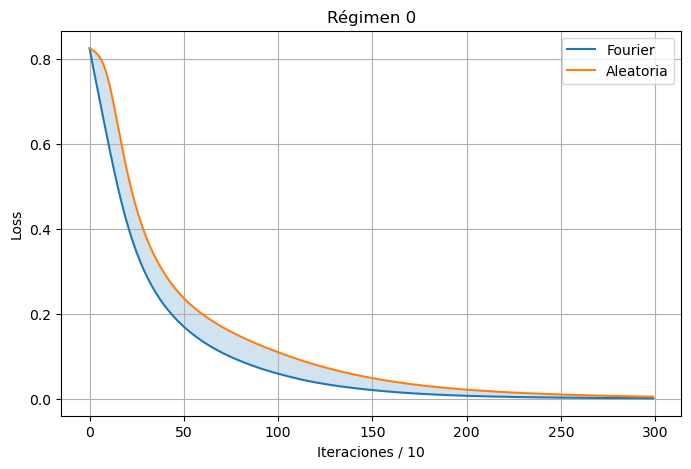

'\nProbé loglog representacion. En mi entrenamiento la escala lineal permitía\napreciar mejor la diferencia entre ambas inicializaciones durante las primeras\niteraciones y la convergencia final, por eso preferí esa visualización para\ncomunicar mejor el resultado.\n'

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    hist_fourier_0,
    label="Fourier"
)
plt.grid(True)
plt.plot(
    hist_random_0,
    label="Aleatoria"
)


plt.fill_between(
    range(len(hist_fourier_0)),
    hist_fourier_0,
    hist_random_0,
    alpha=0.2
)

plt.xlabel("Iteraciones / 10")
plt.ylabel("Loss")

plt.title(
    "Régimen 0"
)

plt.legend()

plt.show()
"""
Probé loglog representacion. En mi entrenamiento la escala lineal permitía
apreciar mejor la diferencia entre ambas inicializaciones durante las primeras
iteraciones y la convergencia final, por eso preferí esa visualización para
comunicar mejor el resultado.
"""

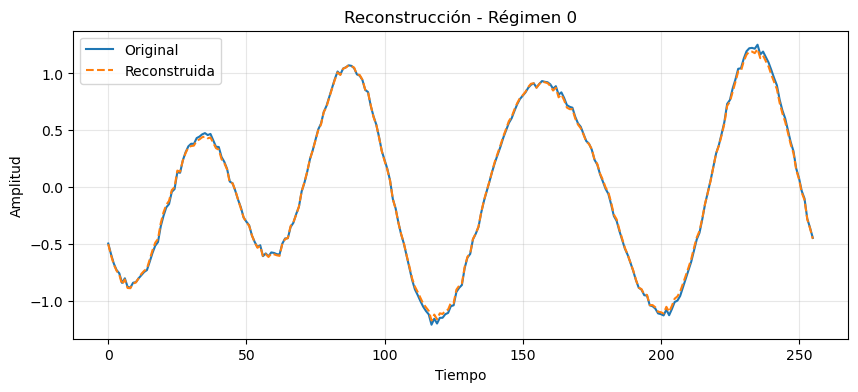

In [26]:
x0 = X0[0]

x0_hat = red(
    params_fourier_0,
    x0
)

plt.figure(figsize=(10,4))

plt.plot(
    x0,
    label="Original"
)

plt.plot(
    np.array(x0_hat),
    "--",
    label="Reconstruida"
)

plt.grid(alpha=0.3)

plt.title(
    "Reconstrucción - Régimen 0"
)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()

plt.show()

In [27]:
err0 = error_relativo(
    x0,
    x0_hat
)

print(
    f"Error relativo régimen 0: {err0:.4f}"
)

Error relativo régimen 0: 0.0242


# **Regimen 1**

In [28]:
params_fourier_1 = init_fourier()

params_fourier_1, hist_fourier_1 = train(
    params=params_fourier_1,
    X=X1,
    epochs=3000
)

In [29]:
params_random_1 = init_random()

params_random_1, hist_random_1 = train(
    params_random_1,
    X1,
    epochs=3000
)

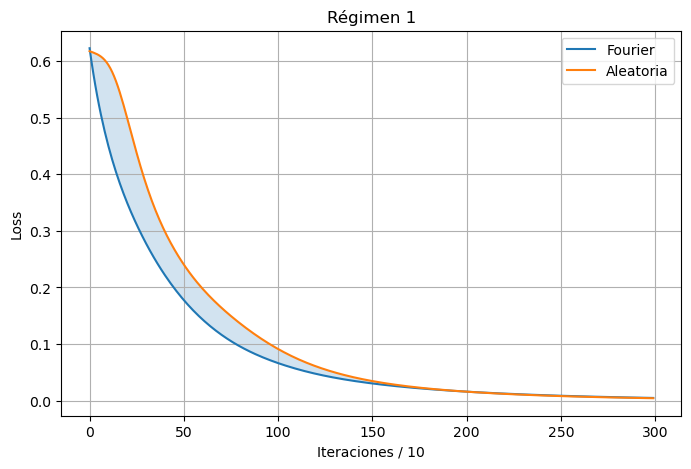

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    hist_fourier_1,
    label="Fourier"
)
plt.grid(True)
plt.plot(
    hist_random_1,
    label="Aleatoria"
)

plt.fill_between(
    range(len(hist_fourier_1)),
    hist_fourier_1,
    hist_random_1,
    alpha=0.2
)
plt.xlabel("Iteraciones / 10")
plt.ylabel("Loss")

plt.title("Régimen 1")

plt.legend()

plt.show()

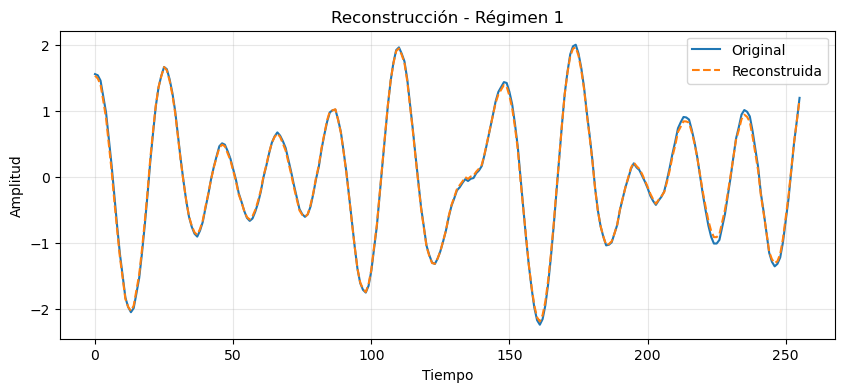

In [31]:
x1 = X1[0]

x1_hat = red(
    params_fourier_1,
    x1
)

plt.figure(figsize=(10,4))

plt.plot(
    x1,
    label="Original"
)

plt.plot(
    np.array(x1_hat),
    "--",
    label="Reconstruida"
)

plt.grid(alpha=0.3)

plt.title(
    "Reconstrucción - Régimen 1"
)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()

plt.show()

In [32]:
err1 = error_relativo(
    x1,
    x1_hat
)

print(
    f"Error relativo régimen 1: {err1:.4f}"
)

Error relativo régimen 1: 0.0368


# **Regimen 2**

In [33]:
params_fourier_2 = init_fourier()

params_fourier_2, hist_fourier_2 = train(
    params_fourier_2,
    X2,
    epochs=3000
)

In [34]:
params_random_2 = init_random()

params_random_2, hist_random_2 = train(
    params_random_2,
    X2,
    epochs=3000
)

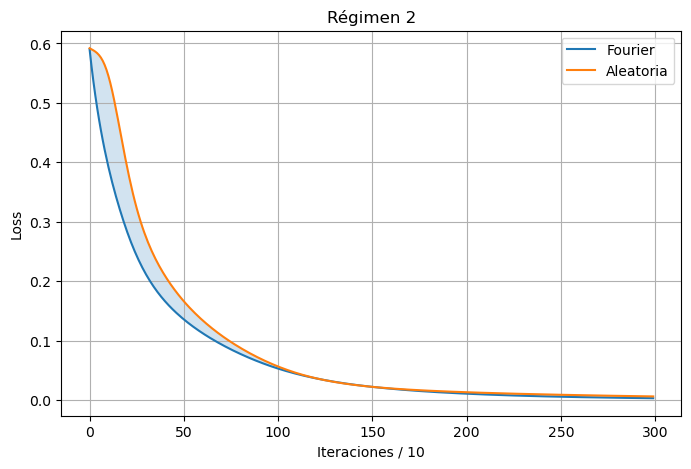

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    hist_fourier_2,
    label="Fourier"
)
plt.grid(True)
plt.plot(
    hist_random_2,
    label="Aleatoria"
)

plt.fill_between(
    range(len(hist_fourier_2)),
    hist_fourier_2,
    hist_random_2,
    alpha=0.2
)
plt.xlabel("Iteraciones / 10")
plt.ylabel("Loss")

plt.title("Régimen 2")

plt.legend()

plt.show()

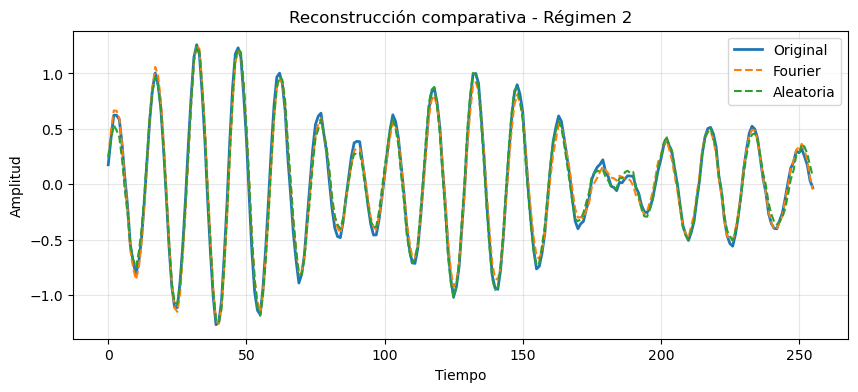

In [36]:
x2 = X2[0]

x2_hat_fourier = red(
    params_fourier_2,
    x2
)

x2_hat_random = red(
    params_random_2,
    x2
)

plt.figure(figsize=(10,4))

plt.plot(
    x2,
    label="Original",
    linewidth=2
)

plt.plot(
    np.array(x2_hat_fourier),
    "--",
    label="Fourier"
)

plt.plot(
    np.array(x2_hat_random),
    "--",
    label="Aleatoria"
)

plt.grid(alpha=0.3)

plt.title(
    "Reconstrucción comparativa - Régimen 2"
)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")

plt.legend()
plt.grid(True)
plt.show()
# Recontruccion con aleatorio por la curiosidad de la grafica anterior

In [37]:
err2_fourier = error_relativo(
    x2,
    x2_hat_fourier
)

err2_random = error_relativo(
    x2,
    x2_hat_random
)

print(
    f"Error relativo régimen 2 (Fourier): {err2_fourier:.4f}"
)
print(
    f"Error relativo régimen 2 (Aleatoria): {err2_random:.4f}"
)

Error relativo régimen 2 (Fourier): 0.1171
Error relativo régimen 2 (Aleatoria): 0.1176


# Conclusión

En general, los resultados muestran que la inicialización Fourier favorece una convergencia más rápida y proporciona una representación adecuada de las señales desde el inicio del entrenamiento.

Aunque en el régimen 2 la inicialización aleatoria alcanza una pérdida final ligeramente menor, esta diferencia no se traduce en una mejora apreciable de la reconstrucción. Por ello, los resultados sugieren que la inicialización Fourier ofrece un mejor desempeño global, especialmente en términos de velocidad de convergencia.

# **Dato Copilados**

In [38]:
print("Errores relativos")
print("------------------")

print(
    f"Régimen 0 : {err0:.4f}"
)

print(
    f"Régimen 1 : {err1:.4f}"
)

print(
    f"Régimen 2 : {err2_fourier:.4f}"
)

Errores relativos
------------------
Régimen 0 : 0.0242
Régimen 1 : 0.0368
Régimen 2 : 0.1171


In [39]:
print("Loss final")

print(f"Régimen 0: {hist_fourier_0[-1]:.4f}")
print(f"Régimen 1: {hist_fourier_1[-1]:.4f}")
print(f"Régimen 2: {hist_fourier_2[-1]:.4f}")

Loss final
Régimen 0: 0.0008
Régimen 1: 0.0046
Régimen 2: 0.0033


In [40]:
n_coef = np.argmax(
    fraccion >= 0.90
) + 1

print(
    f"Coeficientes necesarios: {n_coef}"
)

print(
    f"Fracción de energía: {fraccion[n_coef-1]:.3f}"
)

Coeficientes necesarios: 3
Fracción de energía: 0.999


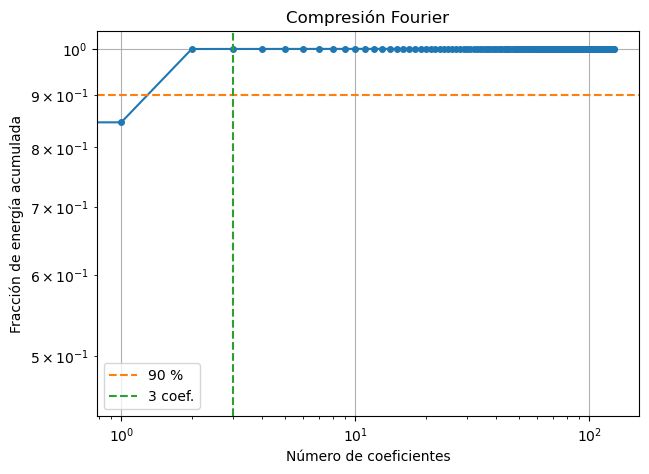

In [41]:
plt.figure(figsize=(7,5))



plt.loglog(fraccion, '-o', markersize=4)

plt.axhline(0.90, color='C1', linestyle='--', label='90 %')
plt.axvline(n_coef, color='C2', linestyle='--',
            label=f'{n_coef} coef.')

plt.xlabel("Número de coeficientes")
plt.ylabel("Fracción de energía acumulada")
plt.title("Compresión Fourier")
plt.grid(True)
plt.legend()

plt.show()


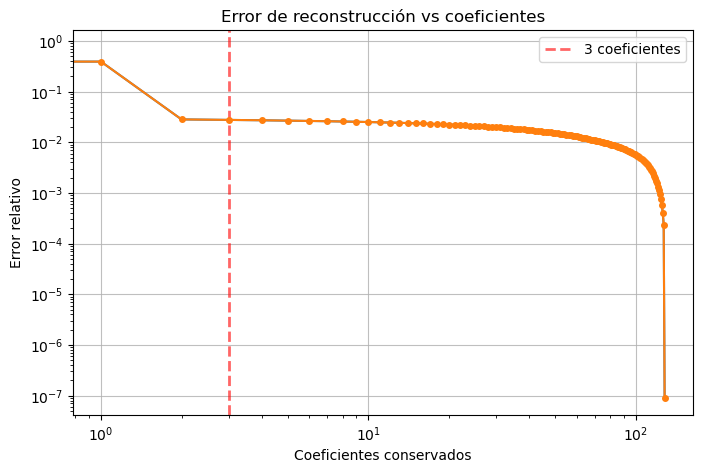

In [42]:
plt.figure(figsize=(8,5))

plt.axvline(
    3,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='3 coeficientes'
)

plt.loglog(
    errores
)

plt.grid(alpha=0.8)

plt.xlabel(
    "Coeficientes conservados"
)

plt.ylabel(
    "Error relativo"
)

plt.title(
    "Error de reconstrucción vs coeficientes"
)

plt.loglog(
    errores,
    marker='o',
    linestyle='-',
    markersize=4
)
plt.legend()
plt.show()

La señal alcanza el 85% de la energía usando solamente 3 coeficientes de Fourier. Esto indica que gran parte de la información está concentrada en pocas frecuencias dominantes.

La proyección de la señal sobre la base de senos y cosenos genera un conjunto de coeficientes espectrales que describen el contenido frecuencial de la señal. Esto confirma que la capa inicial implementa una representación tipo Fourier y permite identificar qué componentes concentran la mayor parte de la información.